## Preliminary Evolutionary Experiments
Can you evolve fw and bw walkers then identify a pair that has fairly similar average activity levels, and then hand-design (numerically) an HP mechanism that's centered around both of them and test its performance in the vicinity of both


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

Start off by assuming that all evolutions succeeded, and if it identifies one that is bad, I'll throw it out manually. since my data saving didn't work

In [ ]:
#forward walkers
avg_vals_forward = np.zeros((100,2))
for i in range(100):
    traj = np.loadtxt("./Forward Walkers/%s/trajectory.dat" % i)
    left = 0
    returned = 0
    avg = np.zeros(2)
    j = 0
    while not returned and j < len(traj):
        dist = np.linalg.norm(traj[j] - traj[0])
        avg += traj[j]
        if dist > 0.015 and left==0:
            left = 1
        if dist < 0.015 and left==1:
            returned = 1
            break
        j += 1
    if j == len(traj):
        if not left:
            print("%s never left" % i)
        else:
            print("%s never returned" % i)
    avg = avg/j
    if returned:
        avg_vals_forward[i] = avg


46 never left
49 never left
70 never left


In [33]:
avg_vals_backward = np.zeros((100,2))
for i in range(100):
    traj = np.loadtxt("./Backward Walkers/%s/trajectory.dat" % i)
    left = 0
    returned = 0
    avg = np.zeros(2)
    j = 0
    while not returned and j < len(traj):
        dist = np.linalg.norm(traj[j] - traj[0])
        avg += traj[j]
        if dist > 0.015 and left==0:
            left = 1
        if dist < 0.015 and left==1:
            returned = 1
            break
        j += 1
    if j == len(traj):
        if not left:
            print("%s never left" % i)
        else:
            print("%s never returned" % i)
    avg = avg/j
    if returned:
        avg_vals_backward[i] = avg

13 never returned
15 never returned
19 never returned
21 never returned
22 never returned
23 never returned
29 never returned
34 never returned
42 never left
45 never returned
47 never returned
54 never returned
59 never returned
63 never returned
72 never returned
87 never left
93 never returned


In [34]:
avg_vals_forward = avg_vals_forward[avg_vals_forward[:,0]!=0]
avg_vals_backward = avg_vals_backward[avg_vals_backward[:,0]!=0]   

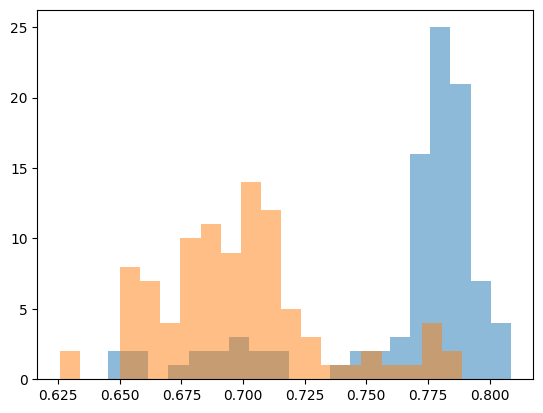

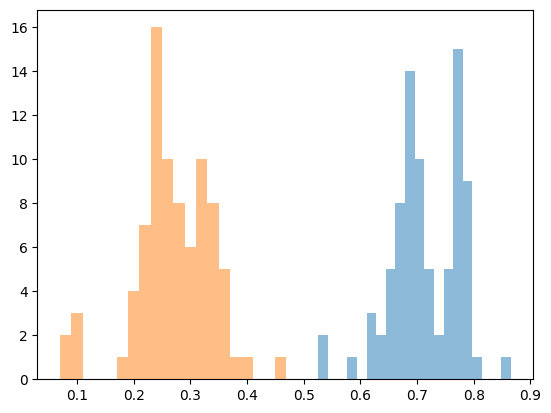

In [35]:
plt.hist(avg_vals_forward[:,0], bins=20, alpha=0.5, label='Forward Walkers, N1')
plt.hist(avg_vals_forward[:,1], bins=20, alpha=0.5, label='Forward Walkers, N2')
plt.show()
plt.hist(avg_vals_backward[:,0], bins=20, alpha=0.5, label='Backward Walkers,N1')
plt.hist(avg_vals_backward[:,1], bins=20, alpha=0.5, label='Backward Walkers,N2')
plt.show()


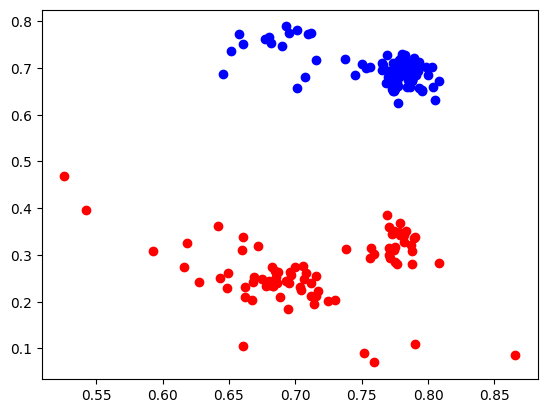

In [36]:
plt.scatter(avg_vals_forward[:,0], avg_vals_forward[:,1], color='blue', label='Forward Walkers')
plt.scatter(avg_vals_backward[:,0], avg_vals_backward[:,1], color='red', label='Backward Walkers')
plt.show()

Relatively bad backward walker 20


In [37]:
print(avg_vals_backward[20])
avg_vals_backward = np.delete(avg_vals_backward,20,0)
print(avg_vals_backward[20])

[0.76941799 0.38492308]
[0.59268017 0.30940751]


In [38]:
min_dist = 1
minidx = [0,0]
for i in range(len(avg_vals_forward)):
    for j in range(len(avg_vals_backward)):
        dist = np.linalg.norm(avg_vals_forward[i] - avg_vals_backward[j])
        if dist < min_dist:
            min_dist = dist
            minidx = [i,j]
print(min_dist,minidx)

0.2483741682568873 [68, 30]


Now comes the challenge. Designing an HP mechanism that centers both is not as simple as extending the range to fit both. I've used the closest points as a starting place, but they're still far apart. I will use an algorithm that, 

for each neuron,

determine the inclusive range that spans the range of both forward and backward walker

for every value in that range, set the minimum

scan across all maximums in that range

check which resulting range centers both the fw and bw walker's neuron the best

store the best range for comparison with subsequent slices

In [39]:
def eval_roc(traj_forward, traj_backward, n_idx, lb, ub):
    drive = np.zeros(2)
    for i in range(len(traj_forward)):
        if traj_forward[i][n_idx] < lb:
            drive[0] += -traj_forward[i][n_idx] + lb
        elif traj_forward[i][n_idx] > ub:
            drive[0] += -traj_forward[i][n_idx] + ub
        if traj_backward[i][n_idx] < lb:
            drive[1] += -traj_backward[i][n_idx] + lb
        elif traj_backward[i][n_idx] > ub:
            drive[1] += -traj_backward[i][n_idx] + ub
    drive = drive/len(traj_forward)
    return drive

In [40]:
fw_idx = 68
bw_idx = 20
res_step = 0.05

traj_forward = np.loadtxt("./Forward Walkers/%s/trajectory.dat" % fw_idx)
traj_backward = np.loadtxt("./Backward Walkers/%s/trajectory.dat" % bw_idx)

In [41]:
#use lb,ub pairs as search variables
final_ranges = np.zeros((2,2))

for neuron_idx in range(2):
    print ("Neuron %s" % neuron_idx)
    fw_max = np.max(traj_forward[:,neuron_idx])
    fw_min = np.min(traj_forward[:,neuron_idx])
    bw_max = np.max(traj_backward[:,neuron_idx])
    bw_min = np.min(traj_backward[:,neuron_idx])

    best_ranges = np.zeros((len(np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step)),2))
    best_sum_drives = np.zeros(len(np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step)))
    i = 0
    for lbval in np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step):
        best_range = np.zeros(2)
        best_sum_drive = float('inf')
        for ubval in np.arange(lbval, max(fw_max,bw_max), res_step):
            drive = eval_roc(traj_forward, traj_backward, neuron_idx, lbval, ubval)
            if abs(drive).sum() < best_sum_drive:
                best_sum_drive = abs(drive).sum()
                best_range[0] = lbval
                best_range[1] = ubval
        
        best_sum_drives[i] = best_sum_drive
        best_ranges[i] = best_range

        print("lb: %s, ub: %s, sum_drive: %s" % (best_range[0], best_range[1], best_sum_drive))

        i += 1
    final_ranges[neuron_idx] = best_ranges[np.argmin(best_sum_drives)]
print(final_ranges)

Neuron 0
lb: 0.000626279, ub: 0.9506262790000001, sum_drive: 0.03994385713601688
lb: 0.050626279, ub: 0.9506262790000002, sum_drive: 0.031365802424491496
lb: 0.100626279, ub: 0.9506262790000001, sum_drive: 0.021488697805944736
lb: 0.150626279, ub: 0.9506262790000003, sum_drive: 0.011144384139717058
lb: 0.20062627900000002, ub: 0.9506262789999999, sum_drive: 0.0004887166878463562
lb: 0.250626279, ub: 0.9506262789999999, sum_drive: 0.010405584305833314
lb: 0.300626279, ub: 0.9506262789999999, sum_drive: 0.021497440706584974
lb: 0.35062627900000004, ub: 0.9006262789999999, sum_drive: 0.01076100226153499
lb: 0.40062627900000003, ub: 0.9006262789999999, sum_drive: 0.0024670020780783444
lb: 0.450626279, ub: 0.9006262789999999, sum_drive: 0.012229993798124133
lb: 0.500626279, ub: 0.9006262790000004, sum_drive: 0.02394523982788408
lb: 0.550626279, ub: 0.8506262790000003, sum_drive: 0.03533292917021588
lb: 0.600626279, ub: 0.8506262790000002, sum_drive: 0.03297003456404906
lb: 0.650626279, ub: 

So what you end up getting is a tradeoff between the lowest drive and the tightest range. The question is: in context (i.e. considering the surrounding parameter space), how specific of a range do you need to exclude the nonfunctional circuits, and how precisely do you need to target walking? 

This also depends on whether you are closer to any other walkers that are actually ok and are more separable from the nonfunctional ones. We optimized for walking first then for separability, but ideally we could have had the tradeoff

In [42]:
#use lb,range pairs as search variables 
def best_range_calc(fw_idx, bw_idx, res_step, range_limit):
    traj_forward = np.loadtxt("./Forward Walkers/%s/trajectory.dat" % fw_idx)
    traj_backward = np.loadtxt("./Backward Walkers/%s/trajectory.dat" % bw_idx)

    final_ranges = np.zeros((2,2))

    for neuron_idx in range(2):
        print ("Calculating Neuron %s..." % neuron_idx)
        
        fw_max = np.max(traj_forward[:,neuron_idx])
        fw_min = np.min(traj_forward[:,neuron_idx])
        
        bw_max = np.max(traj_backward[:,neuron_idx])
        bw_min = np.min(traj_backward[:,neuron_idx])

        best_ranges = np.zeros((len(np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step)),2))
        best_sum_drives = np.zeros(len(np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step)))
        i = 0
        for lbval in np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step):
            best_range = np.zeros(2)
            best_sum_drive = float('inf')
            for rangeval in np.arange(0, min(range_limit, max(fw_max,bw_max)-lbval), res_step):
                ubval = lbval + rangeval
                drive = eval_roc(traj_forward, traj_backward, neuron_idx, lbval, ubval)
                if abs(drive).sum() < best_sum_drive:
                    best_sum_drive = abs(drive).sum()
                    best_range[0] = lbval
                    best_range[1] = ubval
            
            best_sum_drives[i] = best_sum_drive
            best_ranges[i] = best_range

            # print("lb: %s, ub: %s, sum_drive: %s" % (best_range[0], best_range[1], best_sum_drive))

            i += 1
        final_ranges[neuron_idx] = best_ranges[np.argmin(best_sum_drives)]
    print("Best Ranges: ",final_ranges)
    print("N1 drive: " , eval_roc(traj_forward, traj_backward, 0, final_ranges[0][0], final_ranges[0][1]))
    print("N2 drive: " , eval_roc(traj_forward, traj_backward, 1, final_ranges[1][0], final_ranges[1][1]))
    return final_ranges

In [46]:
res_step = 0.025
range_limit = 0.5 #(Can artificially limit ranges if want)

for fw_idx in range(len(avg_vals_forward)):
    # for bw_idx in range(len(avg_vals_backward)):
    for bw_idx in [38]:
        print("FW idx: %s, BW idx: %s" % (fw_idx, bw_idx))
        final_ranges = best_range_calc(fw_idx, bw_idx, res_step, range_limit)

FW idx: 0, BW idx: 38
Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.67603991 0.82603991]
 [0.2901584  0.7651584 ]]
N1 drive:  [ 0.00025462 -0.0003957 ]
N2 drive:  [-0.05700239  0.07822026]
FW idx: 1, BW idx: 38
Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.57603991 0.85103991]
 [0.2126802  0.6876802 ]]
N1 drive:  [ 0.00082513 -0.0018807 ]
N2 drive:  [-0.11522659  0.00726508]
FW idx: 2, BW idx: 38
Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.40103991 0.87603991]
 [0.40094759 0.87594759]]
N1 drive:  [ 0.03314573 -0.01773705]
N2 drive:  [-0.01249049  0.17986283]
FW idx: 3, BW idx: 38
Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.67603991 0.82603991]
 [0.25335463 0.72835463]]
N1 drive:  [ 0.00055583 -0.0003957 ]
N2 drive:  [-0.05735929  0.04432537]
FW idx: 4, BW idx: 38
Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.45103991 0.87603991]
 [0.30946069 0.78446069]]
N1 drive:  [-0.00022609 -0.00

KeyboardInterrupt: 

It seems like proximity of native averages is not so important, and that when you consider nonzero ranges, you can get much better agreement among seemingly more dissimilar patterns. This makes sense. It's like all bets are off. You can essentially just weight different parts of your cycle differently or discount them altogether. 

In [ ]:
fw_idx = 3
bw_idx = 38
final_ranges = best_range_calc(fw_idx, bw_idx, res_step, range_limit)

Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.67603991 0.82603991]
 [0.2901584  0.7651584 ]]
N1 drive:  [ 0.00025462 -0.0003957 ]
N2 drive:  [-0.05700239  0.07822026]


In [47]:

print(-(0.67603991 -0.82603991))
print(-(0.25335463 -0.72835463))

0.15000000000000002
0.475


fitness of fw0 = .55
fitness of bw38 = -.55

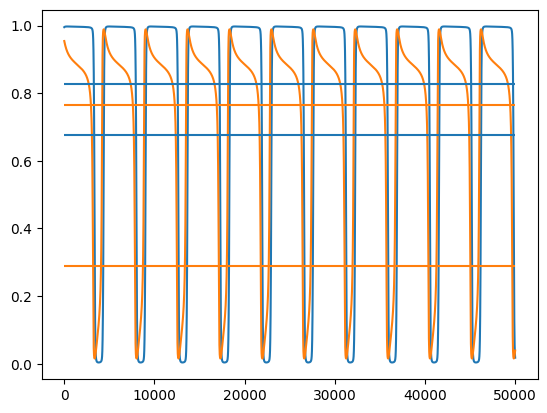

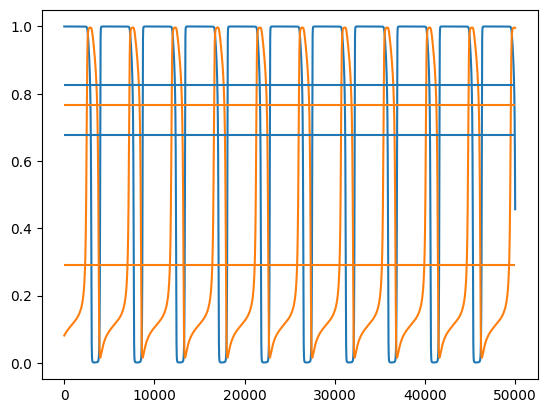

In [ ]:
traj_forward = np.loadtxt("./Forward Walkers/%s/trajectory.dat" % fw_idx)
traj_backward = np.loadtxt("./Backward Walkers/%s/trajectory.dat" % bw_idx)
plt.plot(traj_forward[:,0], label='N1')
plt.plot(traj_forward[:,1], label='N2')
plt.hlines(final_ranges[0][0], 0, len(traj_forward[:,0]), color='tab:blue', label='N1 LB')
plt.hlines(final_ranges[0][1], 0, len(traj_forward[:,0]), color='tab:blue', label='N1 UB')
plt.hlines(final_ranges[1][0], 0, len(traj_forward[:,0]), color='tab:orange', label='N2 LB ')  
plt.hlines(final_ranges[1][1], 0, len(traj_forward[:,0]), color='tab:orange', label='N2 UB')  
plt.show()
plt.plot(traj_backward[:,0], label='N1')
plt.plot(traj_backward[:,1], label='N2')
plt.hlines(final_ranges[0][0], 0, len(traj_backward[:,0]), color='tab:blue', label='N1 LB')
plt.hlines(final_ranges[0][1], 0, len(traj_backward[:,0]), color='tab:blue', label='N1 UB')
plt.hlines(final_ranges[1][0], 0, len(traj_backward[:,0]), color='tab:orange', label='N2 LB ')  
plt.hlines(final_ranges[1][1], 0, len(traj_backward[:,0]), color='tab:orange', label='N2 UB')  
plt.show()

You can definitely get pretty good with the foot neuron in these two, but the force neuron is too different. That makes sense. The foot neuron should just be down for whichever phase is long (according to the physics). But the force neuron should either be high during the long phase or low during the long phase, depending on direction. The only way to truly equalize them is to make the stance and swing phases the same length, with only the phase difference to the foot changing between gaits. But this would necessarily be sub-optimal. 

I bet we could get different results with a walker that was really kinda bad at both gaits, but just swapped between in-phase and out-of-phase

interestingly, the ones that seem to do okay with generalization are those that "lead" with the force neuron instead of the better strategy which is to lead with the foot neuron. This means that the force isn't sustainted at max for as long

So now, the move would be to actually implement ADHP with those ranges on fw and bw walkers *separately* and see if the steady state results are still walkers. It works sometimes. Unpredictably based on the smallest drives (which I assume are bc of inseparable/mixed performance attractors). But one solution I found is forward #3, backward #38 with lbs: 0.67604 0.253355, ubs: 0.82604 0.728355

Another possibility is to use the sliding window...but i worry this might also ruin the separability... but it might not. 